[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Two story planar frame vibration

Last updated: 07/12/26

## Problem description

Planar frame of two stories, vibrating only in the plane.
The frame members are automatically refined into multiple elements.

Analytical solutions are available for the first few modes of vibration.

## References

SCIA Engineer 24.0.1020 test case SDLX 01/89

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [46]:
import context
from pystran import model
from pystran import section
from pystran import plots

The material is steel, SI units (m).


In [47]:
E = 2.1e11
rho = 7.85e3
H = 29.0e-3  # millimeters to meters
B = 4.8e-3
A = H * B
I = H * B**3 / 12

In [48]:
m = model.create(2)
freedoms = m["freedoms"]

In [49]:
model.add_joint(m, 1, [-0.3, 0.0])
model.add_joint(m, 2, [-0.3, 0.810])
model.add_joint(m, 3, [0.3, 0.0])
model.add_joint(m, 4, [0.3, 0.810])
model.add_joint(m, 5, [-0.3, 0.360])
model.add_joint(m, 6, [0.3, 0.360])

{'jid': 6, 'coordinates': array([0.3 , 0.36])}

In [50]:
for jid in [1, 3]:
    model.add_support(m["joints"][jid], freedoms.ALL_DOFS)

In [51]:
s1 = section.beam_2d_section("section_1", E, A, I, rho)

In [52]:
model.add_beam_member(m, 1, [5, 1], s1)
model.add_beam_member(m, 2, [2, 5], s1)
model.add_beam_member(m, 3, [2, 4], s1)
model.add_beam_member(m, 4, [6, 4], s1)
model.add_beam_member(m, 5, [6, 3], s1)
model.add_beam_member(m, 6, [6, 5], s1)

{'mid': 6,
 'connectivity': [6, 5],
 'section': {'name': 'section_1',
  'E': 210000000000.0,
  'rho': 7850.0,
  'CTE': 0.0,
  'A': 0.0001392,
  'I': 2.6726399999999995e-10}}

The structure before refinement: one finite element per member.

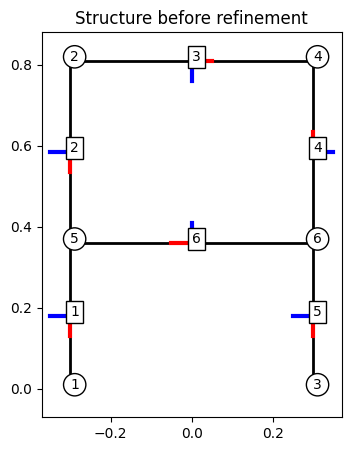

In [53]:
plots.setup(m, set_limits=True)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_member_orientation(m, 0.05)
ax = plots.plot_joint_ids(m)
ax.set_title("Structure before refinement")
plots.show(m)

All members will now be refined into eight finite elements. Without the
refinement, the reference solutions cannot be reproduced: there simply
wouldn't be enough degrees of freedom. Unfortunately the reference publication
does not mention the numbers of finite elements used per member.


In [54]:
nref = 8
for i in range(6):
    model.refine_member(m, i + 1, nref)

Let us review the structure after refinement:

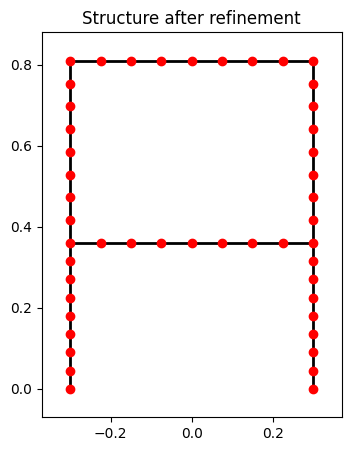

In [55]:
plots.setup(m, set_limits=True)
plots.plot_members(m)
ax = plots.plot_joints(m)
ax.set_title("Structure after refinement")
plots.show(m)

Solve a free vibration analysis problem.


In [56]:
model.number_dofs(m)
model.solve_free_vibration(m)

Compare with the reference frequencies.


In [57]:
reffs = [8.75, 29.34, 43.71, 56.12, 95.86, 102.37, 146.64, 174.39, 178.36]
for mode, reff in enumerate(reffs):
    print(f'Mode {mode}: {m["frequencies"][mode]} vs {reff} Hz')
    if abs((m["frequencies"][mode] - reff) / reff) > 1e-2:
        raise ValueError("Incorrect frequency")

Mode 0: 8.753501396541195 vs 8.75 Hz
Mode 1: 29.346257778268527 vs 29.34 Hz
Mode 2: 43.70897504958224 vs 43.71 Hz
Mode 3: 56.12412843787187 vs 56.12 Hz
Mode 4: 95.88346437573486 vs 95.86 Hz
Mode 5: 102.3777388415145 vs 102.37 Hz
Mode 6: 146.68253704053006 vs 146.64 Hz
Mode 7: 174.40451303358012 vs 174.39 Hz
Mode 8: 178.4264954106738 vs 178.36 Hz


Show the first four modes.


Mode 0:  8.753501396541195


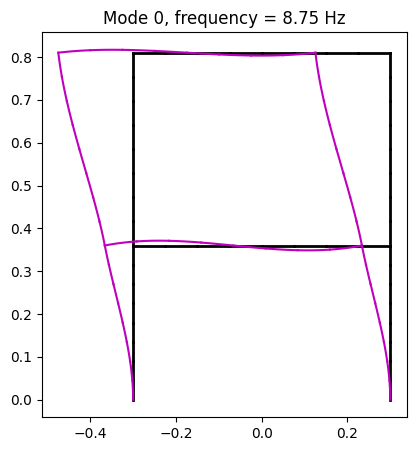

Mode 1:  29.346257778268527


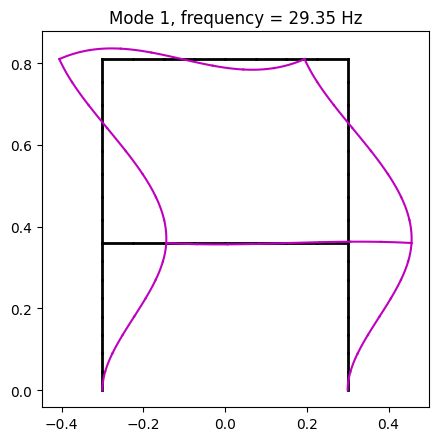

Mode 2:  43.70897504958224


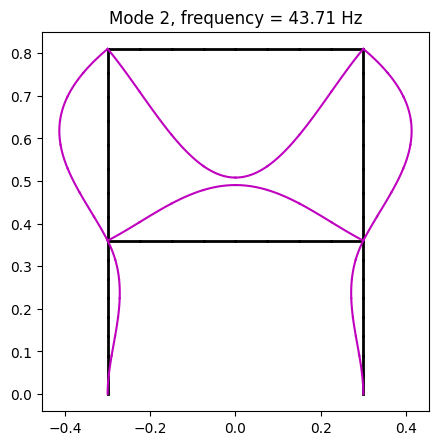

Mode 3:  56.12412843787187


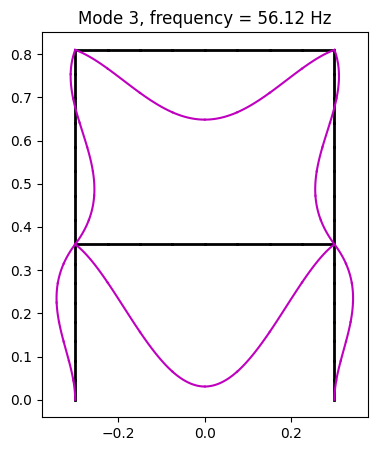

In [58]:
for mode in range(0, 4):
    print(f"Mode {mode}: ", m["frequencies"][mode])
    ax = plots.setup(m)
    plots.plot_members(m)
    model.set_solution(m, m["eigvecs"][:, mode])
    plots.plot_deformations(m, 0.2)
    ax.set_title(f"Mode {mode}, frequency = {m['frequencies'][mode]:.2f} Hz")
    plots.show(m)